# Customer Churn Dataset

“Which customers are likely to leave the bank and why?”

Business Objective:
we are trying to predict customers who will leave in future and identify what drives them into churning.


In [208]:
#importing necessary libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Folder to save plots
save_folder = "eda_plots"
os.makedirs(save_folder, exist_ok=True)

In [209]:
#load the dataset
df = pd.read_csv("/Users/niharikabisoyi/PyCharmMiscProject/Customer_churn/data/Customer-Churn-Records.csv")
print("Dataset Shape:", df.shape)
df.head(3)

Dataset Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377


Dataset has 10000 records and 18 features including target feature 'Exited'

#### Dataset Overview

In [210]:
print(df.info())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

Dataset contains no missing values or duplicates, making it clean for analysis.

In [211]:
# Drop duplicates
df.drop_duplicates(inplace=True)

A### Features:

**RowNumber** (int64) — A simple index column, not useful for modeling.

**CustomerId** (int64) — A unique identifier for each customer, also irrelevant for prediction.

**Surname** (object) — The customer’s surname. This doesn’t impact churn at all, so it could also be dropped.

**CreditScore** (int64) — A numeric score indicating the customer’s credit score. Lower scores may correlate with higher churn rates.

**Geography** (object) — The customer’s country of residence. This feature includes three countries: France, Spain, and Germany.

**Gender** (object) — The customer’s gender

**Age** (int64) — The customer’s age.

**Tenure** (int64) — The number of years the customer has been with the bank.

**Balance** (float64) — The customer’s account balance.

**NumOfProducts** (int64) — The number of products the customer uses.

**HasCrCard** (int64) — A binary indicator (1 = has credit card, 0 = doesn’t).

**IsActiveMember** (int64) — A binary indicator of whether the customer is actively engaging with bank services (1 = active, 0 = inactive).

**EstimatedSalary** (float64) — The customer’s estimated salary.

**Exited** (int64) — Target variable (1 = churned, 0 = retained). This is what we aim to predict.

**Complain** (int64) — Whether the customer has filed complaints (1 = complained, 0 = did not).

**Satisfaction** Score (int64) — A rating that likely reflects customer satisfaction.

**Card Type** (object) — The type of bank card a customer holds (e.g., Platinum, Gold).

**Point Earned** (int64) — The number of reward points a customer has earned.

In [212]:
#Drop Irrelevant Columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

#### Why removed?
- These columns do not contribute to churn prediction

##### **Target Variable Analysis**

In [213]:
print(df['Exited'].value_counts(normalize=True)*100)
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette=['skyblue','orange'])
plt.title("Target Distribution (Exited)")
plt.savefig(f"{save_folder}/Target_distribution.png", dpi=300)
plt.close()

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


* Insight

Churn rate ≈ 20%
Dataset is imbalanced
*  Business Impact

Accuracy is not reliable → use F1-score and ROC-AUC

Remove leakage feature

In [214]:
df.drop('Complain', axis=1, inplace=True)

#### Important
- 'Complain' has perfect correlation with churn
- This causes data leakage → removed

#### Univariate Analysis

**Numerical Feature**:

We can check numerical distribution here by plotting them.
we will create bins for 'Age' and 'Credit Score' to have proper detailed analysis.

In [215]:
#statistical summary of numerical features
df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'Point Earned']].describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.0,584.0,652.00,718.00,850.00
Age,10000.0,38.921800,10.487806,18.0,32.0,37.00,44.00,92.00
Tenure,10000.0,5.012800,2.892174,0.0,3.0,5.00,7.00,10.00
Balance,10000.0,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.0,1.0,1.00,2.00,4.00
Point Earned,10000.0,606.515100,225.924839,119.0,410.0,605.00,801.00,1000.00


We will plot histograms to see the distribution and boxplot to see outliers and spread by plotting them side by side.

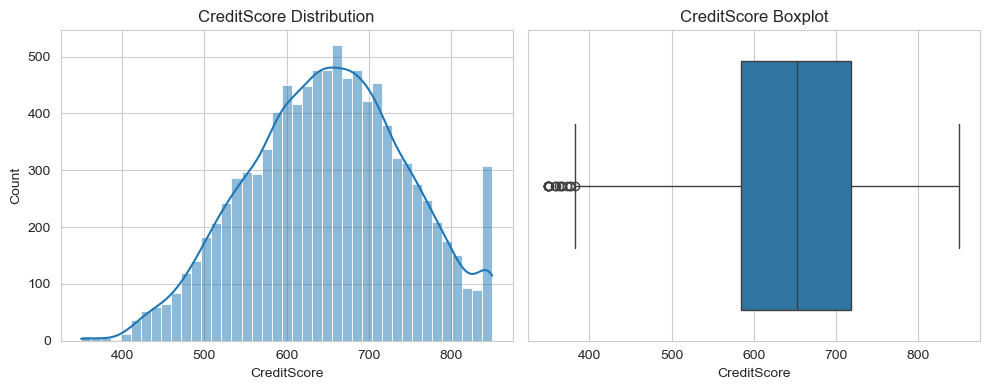

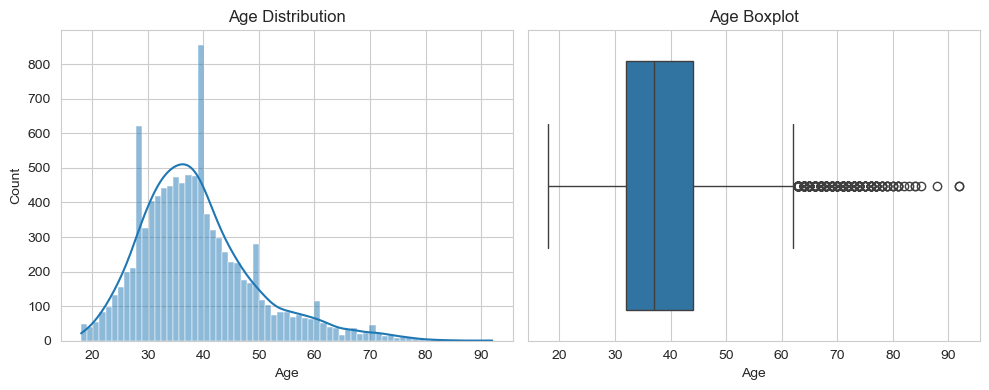

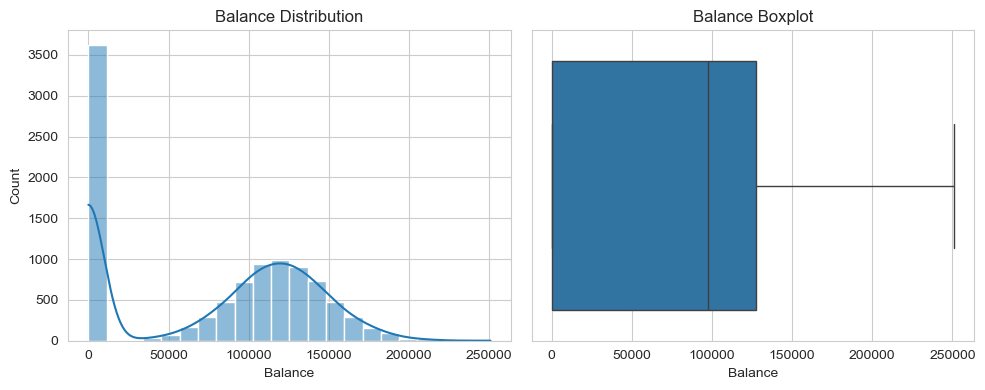

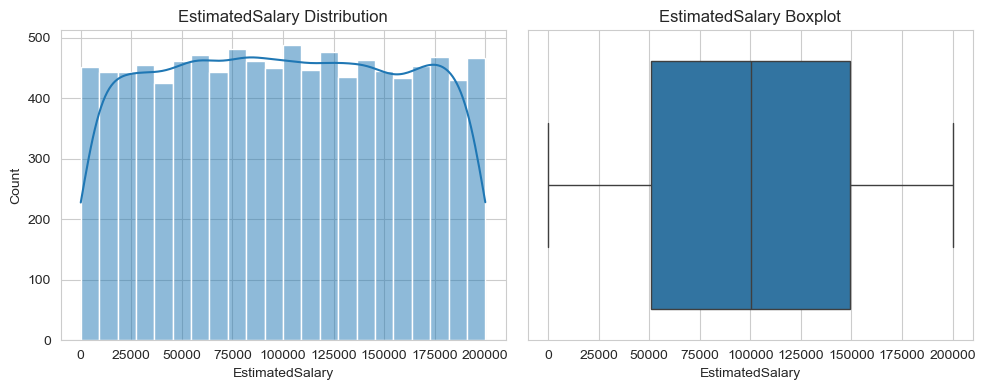

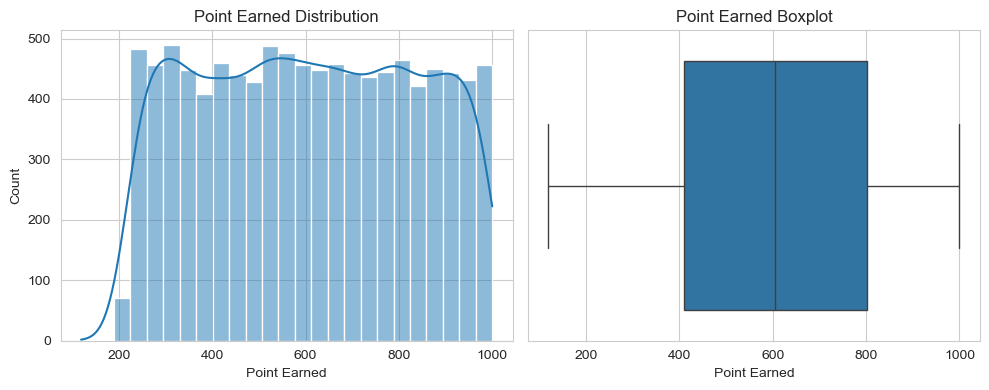

In [216]:
def plot_numeric(df):

    for col in num_cols:
        fig, ax = plt.subplots(1,2, figsize=(10,4))

        sns.histplot(df[col], kde=True, ax=ax[0])
        ax[0].set_title(f"{col} Distribution")

        sns.boxplot(x=df[col], ax=ax[1])
        ax[1].set_title(f"{col} Boxplot")

        plt.tight_layout()

        plt.show()

num_cols = ['CreditScore','Age','Balance','EstimatedSalary','Point Earned']
plot_numeric(df)

Insights

* Balance and Point earned -> strongly right-skewed
* Age -> Moderately right-skewed-> slightly older outliers
* Credit score, Tenure -> approximately symmetric

### Categorical feature plots


Churn rate by Geography:

Geography
France     0.16
Germany    0.32
Spain      0.17
Name: Exited, dtype: float64


<Figure size 500x300 with 0 Axes>

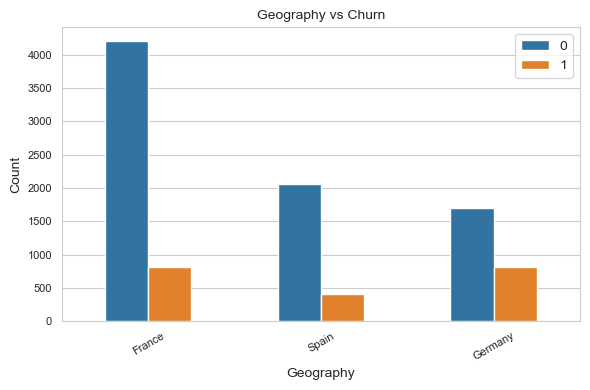


Churn rate by Gender:

Gender
Female    0.25
Male      0.16
Name: Exited, dtype: float64


<Figure size 500x300 with 0 Axes>

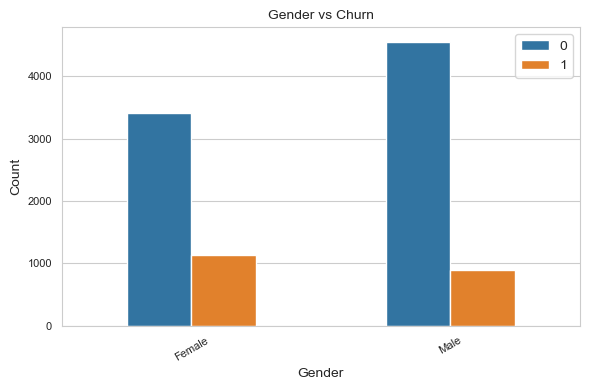


Churn rate by Card Type:

Card Type
DIAMOND     0.22
GOLD        0.19
PLATINUM    0.20
SILVER      0.20
Name: Exited, dtype: float64


<Figure size 500x300 with 0 Axes>

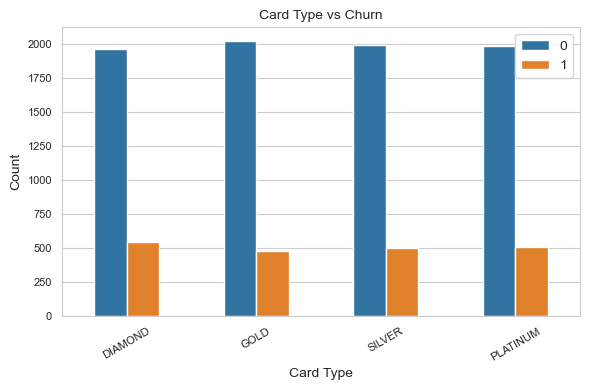

In [217]:
def plot_categorical(df,cat_cols,save_folder="eda_plots"):

    for col in cat_cols:
        plt.figure(figsize=(5,3))

        print(f"\nChurn rate by {col}:\n")
        print(df.groupby(col)['Exited'].mean().round(2))
        plt.figure(figsize=(6,4))

        sns.countplot(x=col,hue='Exited',data=df, width=0.5)

        plt.title(f"{col} vs Churn",fontsize=10)
        plt.xlabel(f"{col}", fontsize=10)
        plt.ylabel("Count", fontsize=10)
        plt.xticks(fontsize=8,rotation = 30)
        plt.yticks(fontsize=8)
        plt.legend(fontsize=10)

        plt.tight_layout()
        plt.show()

cat_cols = ['Geography','Gender','Card Type']
plot_categorical(df,cat_cols)

* We can see more 50% of customers are from France followed by Germany and Spain.
* As for gender, 55% male customer and 45% female.

In [218]:
for col in df.select_dtypes(include='object'):
    print(df.groupby(col)['Exited'].value_counts(normalize=True).round(2))

Geography  Exited
France     0         0.84
           1         0.16
Germany    0         0.68
           1         0.32
Spain      0         0.83
           1         0.17
Name: proportion, dtype: float64
Gender  Exited
Female  0         0.75
        1         0.25
Male    0         0.84
        1         0.16
Name: proportion, dtype: float64
Card Type  Exited
DIAMOND    0         0.78
           1         0.22
GOLD       0         0.81
           1         0.19
PLATINUM   0         0.80
           1         0.20
SILVER     0         0.80
           1         0.20
Name: proportion, dtype: float64


* Customers from France and Germany are more likely to churn compared to Spain.
* Females are more likely to churn as compared to male customer.
* Diamond card types customers are most likely to churn compared to othe card types.

#### Age:
Customers aged between 39 and 51 show a higher likelihood of churn compared to other age groups. In contrast, younger customers and older customers (around 56–90 years) tend to churn less. This suggests that age has a non-linear relationship with churn.

#### Tenure:
Customers with a tenure of 2 to 8 years have a slightly higher churn rate. However, the overall impact of tenure on churn appears to be moderate and not very strong.

#### Balance:
Customers who did not churn have a median balance of around $90k , with most values ranging between $0 and $220,000.

Customers who churned have a slightly higher median balance of about $110k, with a wider spread ranging from $0 to $250,000.

This indicates that higher balance customers may have a slightly higher tendency to churn, but the relationship is not very strong.

#### Estimated Salary & Points Earned:
Both estimated salary and reward points earned show little to no significant relationship with customer churn, indicating they are weak predictors.

#### Bivariate Analysis

Numeric vs Churn:

In [219]:
def plot_numeric_vs_target(df, cols):

    for col in cols:
        plt.figure(figsize=(6,4))

        sns.boxplot(x='Exited', y=col, data=df)

        plt.title(f"{col} vs Churn")
        plt.xlabel("Exited (0 = Retained, 1 = Churned)")
        plt.ylabel(col)

        plt.tight_layout()
        plt.savefig(f"eda_plots/{col}_vs_Exited_box.png", dpi=300)
        plt.close()

num_cols = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Tenure']
plot_numeric_vs_target(df, num_cols)

#### Insights
- Age: Customers aged 38–52 show higher churn
- Balance: Higher median for churned customers
- Salary: Weak relationship with churn

Categorical Vs Target:

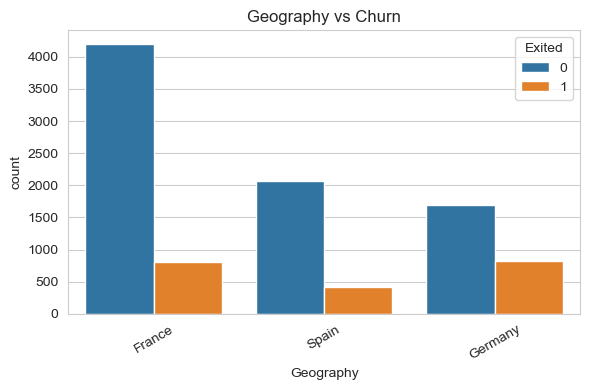

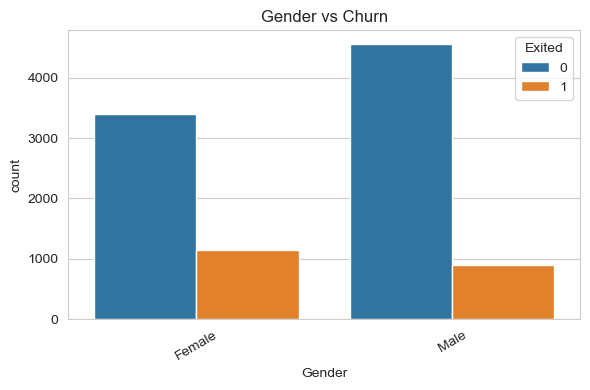

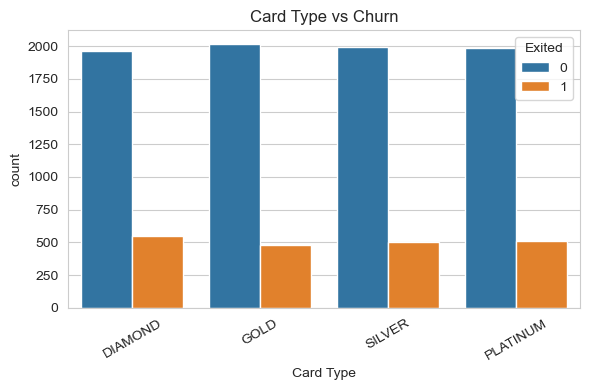

In [220]:
def plot_categorical_vs_target(df, cols):

    for col in cols:
        plt.figure(figsize=(6,4))

        sns.countplot(x=col, hue='Exited', data=df)

        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=30)

        plt.tight_layout()
        plt.savefig(f"eda_plots/{col}_vs_Exited.png", dpi=300)
        plt.show()

cat_cols = ['Geography', 'Gender', 'Card Type']
plot_categorical_vs_target(df, cat_cols)

In [221]:
def churn_rate_table(df, cols):
    for col in cols:
        print(f"\nChurn Rate by {col}:\n")
        print((df.groupby(col)['Exited'].mean()*100).round(2))

churn_rate_table(df, cat_cols)


Churn Rate by Geography:

Geography
France     16.17
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

Churn Rate by Gender:

Gender
Female    25.07
Male      16.47
Name: Exited, dtype: float64

Churn Rate by Card Type:

Card Type
DIAMOND     21.78
GOLD        19.26
PLATINUM    20.36
SILVER      20.11
Name: Exited, dtype: float64


#### Insights
- Germany → highest churn (~32%)
- Female customers → higher churn (~25%)
- Card Type → minor impact

Binary feature Vs Target:

In [222]:
def plot_categorical_vs_target(df, cols):
    for col in cols:
        plt.figure(figsize=(6,4))

        sns.countplot(x=col, hue='Exited', data=df)

        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=30)

        plt.tight_layout()
        plt.savefig(f"eda_plots/{col}_vs_Exited.png", dpi=300)
        plt.close()

binary_cols = ['IsActiveMember', 'HasCrCard', 'NumOfProducts']
plot_categorical_vs_target(df, binary_cols)

#### Insights
- Inactive members → significantly higher churn
- Products → moderate effect

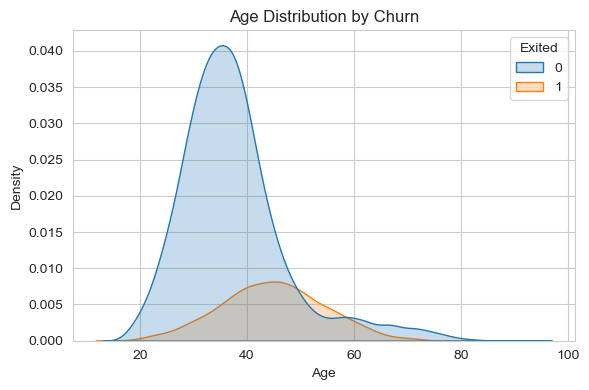

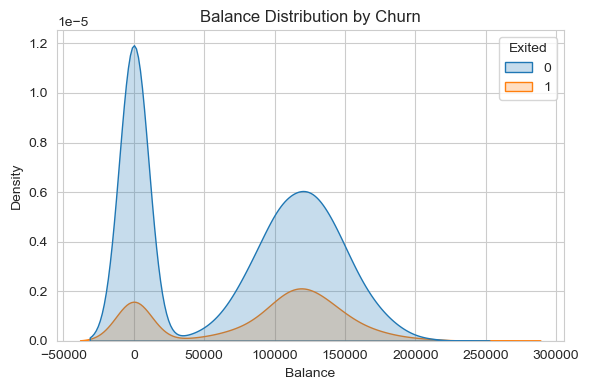

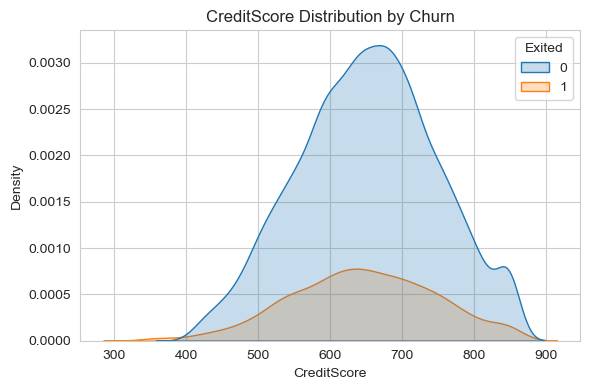

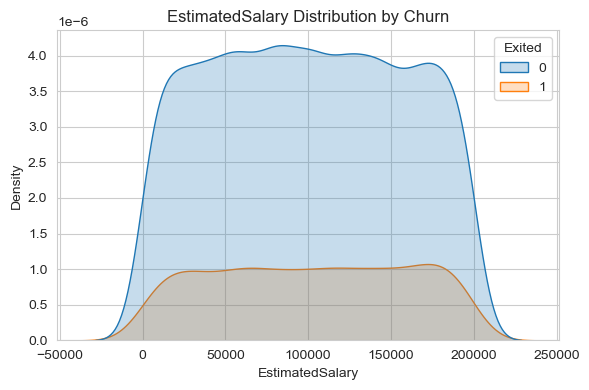

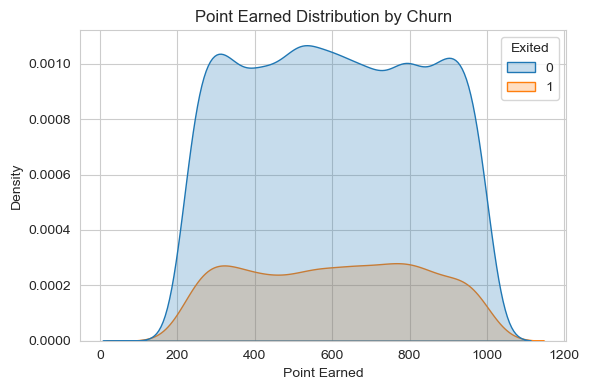

In [223]:
def plot_kde(df, cols):

    for col in cols:
        plt.figure(figsize=(6,4))

        sns.kdeplot(data=df, x=col, hue='Exited', fill=True)

        plt.title(f"{col} Distribution by Churn")

        plt.tight_layout()
        plt.show()

kde_cols = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Point Earned']
plot_kde(df, kde_cols)

#### Age KDE
The distribution of churned customers is shifted toward higher ages, indicating older customers are more likely to churn.

#### Balance KDE
Churned customers show slightly higher balance concentration, but overlap is significant, indicating weak predictive power.

### Segmentation Analysis (EDA ONLY)

Age,salary,credit score bins were created during EDA to understand churn patterns

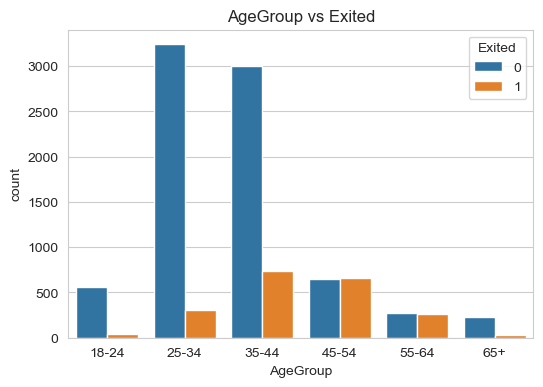

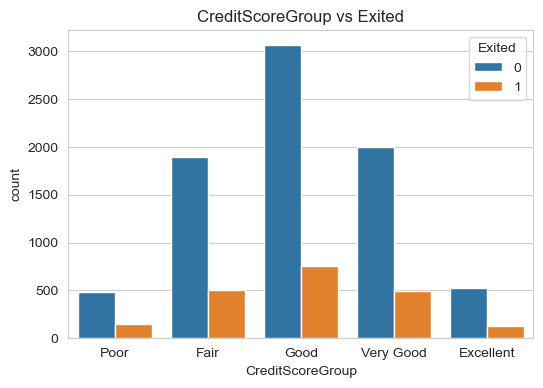

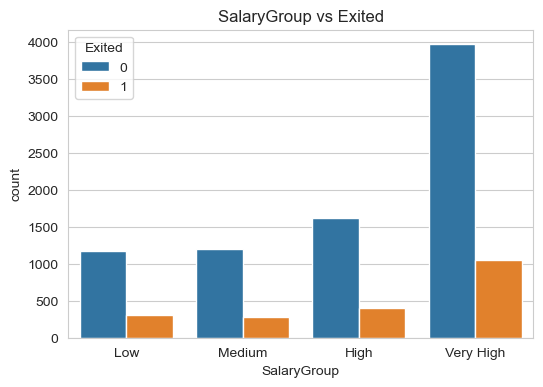

In [224]:
# EDA-only feature creation
df_eda = df.copy()

# Age bins
age_bins = [18,25,35,45,55,65,100]
age_labels = ['18-24','25-34','35-44','45-54','55-64','65+']
df_eda['AgeGroup'] = pd.cut(df_eda['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

# CreditScore bins
cs_bins = [300,500,600,700,800,900]
cs_labels = ['Poor','Fair','Good','Very Good','Excellent']
df_eda['CreditScoreGroup'] = pd.cut(df_eda['CreditScore'], bins=cs_bins, labels=cs_labels, right=False)

# Salary bins
salary_bins = [0,30000,60000,100000,200000]
salary_labels = ['Low','Medium','High','Very High']
df_eda['SalaryGroup'] = pd.cut(df_eda['EstimatedSalary'], bins=salary_bins, labels=salary_labels, right=False)

# Save feature engineered plots
feature_groups = ['AgeGroup','CreditScoreGroup','SalaryGroup']
for col in feature_groups:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Exited', data=df_eda)
    plt.title(f"{col} vs Exited")
   # plt.savefig(f"{save_folder}/{col}_vs_Exited.png", dpi=300)
    plt.show()

#### Note
These features are used ONLY for analysis, not for model training.

we can see here people from 45-54 are leaving the service and younger people from 18-44 and who are older than 65 are continuing with the service.

In [225]:
# List of binned features
binned_features = ['AgeGroup', 'CreditScoreGroup', 'SalaryGroup']

# Loop through and print % of churn
for col in binned_features:
    ct = pd.crosstab(df_eda[col], df_eda['Exited'], normalize='index') * 100
    print(f"\n{col} vs Exited (%):\n")
    print(ct.round(1))


AgeGroup vs Exited (%):

Exited       0     1
AgeGroup            
18-24     92.5   7.5
25-34     91.5   8.5
35-44     80.4  19.6
45-54     49.4  50.6
55-64     51.7  48.3
65+       86.7  13.3

CreditScoreGroup vs Exited (%):

Exited               0     1
CreditScoreGroup            
Poor              76.3  23.7
Fair              78.8  21.2
Good              80.3  19.7
Very Good         80.1  19.9
Excellent         80.5  19.5

SalaryGroup vs Exited (%):

Exited          0     1
SalaryGroup            
Low          79.6  20.4
Medium       80.9  19.1
High         79.9  20.1
Very High    79.1  20.9


### Correlation Analysis

In [226]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap="coolwarm")
plt.xticks(rotation=45)
plt.savefig(f"{save_folder}/correlation_heatmap.png", dpi=300)
plt.close()

In [227]:
df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)

Exited                1.000000
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64

#### Insights
- Age → strongest positive correlation
- IsActiveMember → strong negative correlation
- Salary → weak relationship

In [228]:
print("EDA completed! All plots are saved in:", save_folder)

EDA completed! All plots are saved in: eda_plots


### Final Insights

#### Key Takeaways

- Churn rate is ~20% (imbalanced dataset)
- Customers aged 39–54 are most likely to churn
- Germany shows the highest churn rate
- Female customers churn more than males
- Inactive members are highly likely to churn
- Balance shows slight positive association with churn
- Salary and credit score have minimal impact
- 'Complain' feature removed due to data leakage

#### Business Impact

- Target high-risk customers for retention campaigns
- Focus on mid-age customer segment
- Improve engagement for inactive users